# Regresión Lineal II — Dataset California Housing

En este notebook aplicamos regresión lineal **simple** y **múltiple** sobre el dataset *California Housing*.  
Seguiremos el siguiente flujo de trabajo:

1. Carga del dataset y análisis exploratorio (EDA)  
2. Regresión lineal **simple** (una sola variable predictora)  
3. Regresión lineal **múltiple** (todas las variables)  
4. Detección de **sobreajuste** (overfitting)  
5. **Importancia de variables** mediante coeficientes estandarizados  


# 1. Cargar dataset y EDA previo

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# IMPORTACIONES
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd               # Manipulación de datos tabulares
import matplotlib.pyplot as plt   # Visualización básica
import seaborn as sns             # Visualización estadística
from scipy import stats           # Test estadísticos (p.ej. Pearson)
import os
import numpy as np

# Scikit-learn: herramientas para Machine Learning
from sklearn.linear_model import LinearRegression          # Modelo de regresión lineal
from sklearn.model_selection import train_test_split       # División train/test
from sklearn.metrics import (mean_squared_error,           # Error cuadrático medio (MSE)
                              mean_absolute_error,         # Error absoluto medio (MAE)
                              r2_score)                    # Coeficiente de determinación R²
from sklearn.preprocessing import StandardScaler           # Estandarización de variables

# ─────────────────────────────────────────────────────────────────────────────
# CARGA DEL DATASET
# ─────────────────────────────────────────────────────────────────────────────
# Leemos el CSV con los datos de viviendas en California.
# Cada fila representa un bloque censal con 8 características y el precio mediano.
df = pd.read_csv("california_housing.csv")

# Comprobación rápida: número de filas y valores nulos por columna
print(f"Filas: {df.shape[0]:,}")
print("\nNulos por columna:")
print(df.isnull().sum())

# Resumen estadístico de todas las variables (media, std, cuartiles…)
df.describe().round(2)


Filas: 20,640

Nulos por columna:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,5.07,26.36,5.93,1.34,920.00,3.26,37.26,-119.32,3.66
std,2.60,14.72,2.45,0.58,870.79,1.35,2.71,2.89,1.01
min,0.63,1.00,1.00,0.25,18.00,1.00,32.54,-124.35,0.68
25%,3.21,13.50,4.19,0.92,390.00,2.30,34.91,-121.78,2.90
50%,4.49,26.30,5.49,1.23,666.00,3.01,37.25,-119.33,3.71
75%,6.30,39.10,7.19,1.63,1142.00,3.93,39.60,-116.84,4.58
max,15.00,52.00,24.49,6.45,14240.00,16.13,41.95,-114.31,5.00


Correlación de cada variable con el precio (MedHouseVal):
MedInc        0.675
HouseAge      0.615
Population    0.010
Latitude      0.006
AveRooms      0.006
AveBedrms     0.006
Longitude     0.004
AveOccup      0.002
Name: MedHouseVal, dtype: float64


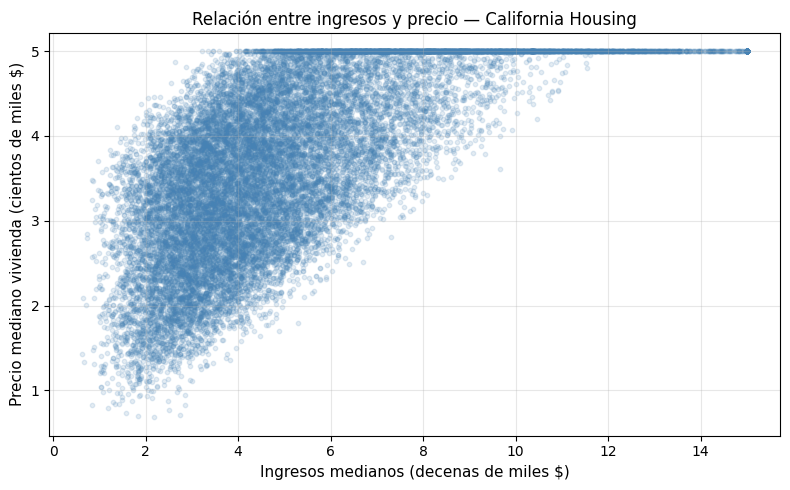


Correlación de Pearson (MedInc vs precio):  r = 0.6748  (p = 0.00e+00)


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# ANÁLISIS DE CORRELACIONES
# ─────────────────────────────────────────────────────────────────────────────

# Calculamos la correlación de Pearson de cada variable con el precio (MedHouseVal).
# Un valor cercano a +1 indica relación positiva fuerte; a -1, negativa fuerte.
corr = df.corr()["MedHouseVal"].drop("MedHouseVal").sort_values(ascending=False)
print("Correlación de cada variable con el precio (MedHouseVal):")
print(corr.round(3))

# ─────────────────────────────────────────────────────────────────────────────
# SCATTER: variable más correlacionada (MedInc) vs precio
# ─────────────────────────────────────────────────────────────────────────────
# MedInc = ingresos medianos del bloque censal (en decenas de miles de dólares).
# Esperamos una relación positiva: a mayor ingreso, mayor precio de vivienda.
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df["MedInc"], df["MedHouseVal"],
           alpha=0.15, s=10, color="steelblue")  # alpha bajo por la alta densidad de puntos
ax.set_xlabel("Ingresos medianos (decenas de miles $)", fontsize=11)
ax.set_ylabel("Precio mediano vivienda (cientos de miles $)", fontsize=11)
ax.set_title("Relación entre ingresos y precio — California Housing", fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# TEST DE PEARSON
# ─────────────────────────────────────────────────────────────────────────────
# stats.pearsonr devuelve:
#   r → coeficiente de correlación lineal   (entre -1 y +1)
#   p → p-valor del contraste H₀: ρ = 0   (si p < 0.05 la correlación es significativa)
r, p_corr = stats.pearsonr(df["MedInc"], df["MedHouseVal"])
print(f"\nCorrelación de Pearson (MedInc vs precio):  r = {r:.4f}  (p = {p_corr:.2e})")


# 2. Regresión lineal simple

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# PREPARACIÓN DE DATOS
# ─────────────────────────────────────────────────────────────────────────────

# Usamos solo MedInc como variable predictora (X).
# Nota: sklearn requiere X en formato 2D → usamos doble corchete [[...]]
X_simple = df[["MedInc"]]   # shape (n, 1)
y = df["MedHouseVal"]       # variable objetivo (precio)

# División en conjunto de entrenamiento (80%) y prueba (20%).
# random_state=42 garantiza reproducibilidad (siempre el mismo reparto).
X_tr, X_te, y_tr, y_te = train_test_split(X_simple, y, test_size=0.2, random_state=42)

# ─────────────────────────────────────────────────────────────────────────────
# ENTRENAMIENTO DEL MODELO
# ─────────────────────────────────────────────────────────────────────────────
# LinearRegression ajusta la recta  ŷ = β₀ + β₁·MedInc
# minimizando la suma de errores cuadráticos (OLS).
modelo_simple = LinearRegression()
modelo_simple.fit(X_tr, y_tr)   # aprendemos β₀ y β₁ a partir de los datos de entrenamiento

# Mostramos los coeficientes aprendidos con su interpretación económica.
# β₀ (intercepto): precio estimado cuando MedInc = 0 (valor teórico, sin interpretación real)
# β₁ (pendiente): incremento de precio por cada unidad de aumento en MedInc
print(f"Intercepto β₀ = {modelo_simple.intercept_:.4f}  (~{modelo_simple.intercept_*100:.0f}.000 $)")
print(f"Pendiente  β₁ = {modelo_simple.coef_[0]:.4f}  (por cada 10k$ más de ingreso, el precio sube ~{modelo_simple.coef_[0]*100:.0f}.000 $)")


Intercepto β₀ = 2.3329  (~233.000 $)
Pendiente  β₁ = 0.2624  (por cada 10k$ más de ingreso, el precio sube ~26.000 $)


── Regresión SIMPLE (solo MedInc) ──
R²:    0.4538  (45.4% de la varianza explicada)
RMSE:  0.7390  (~74.000 $ de error cuadrático medio)
MAE:   0.6196  (~62.000 $ de error absoluto medio)


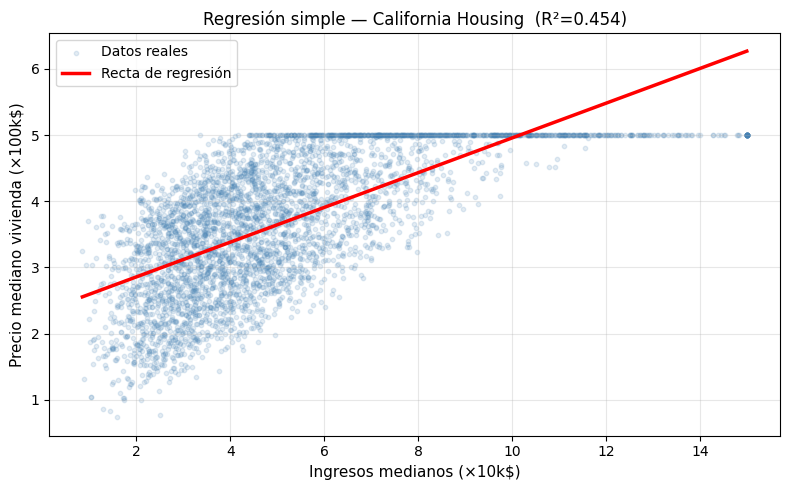

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# PREDICCIÓN Y MÉTRICAS DE EVALUACIÓN — Regresión Simple
# ─────────────────────────────────────────────────────────────────────────────

# Generamos predicciones sobre el conjunto de TEST (datos NO vistos durante el entrenamiento)
y_pred_simple = modelo_simple.predict(X_te)

# ── Métricas ──────────────────────────────────────────────────────────────────
# R² (coeficiente de determinación): proporción de la varianza explicada por el modelo.
#   R² = 1 → ajuste perfecto | R² = 0 → el modelo no mejora la media
r2_s   = r2_score(y_te, y_pred_simple)

# RMSE (raíz del error cuadrático medio): error típico en las mismas unidades que y.
#   Penaliza más los errores grandes que el MAE.
rmse_s = mean_squared_error(y_te, y_pred_simple) ** 0.5

# MAE (error absoluto medio): error promedio en valor absoluto.
#   Más robusto frente a outliers que el RMSE.
mae_s  = mean_absolute_error(y_te, y_pred_simple)

print(f"── Regresión SIMPLE (solo MedInc) ──")
print(f"R²:    {r2_s:.4f}  ({r2_s*100:.1f}% de la varianza explicada)")
print(f"RMSE:  {rmse_s:.4f}  (~{rmse_s*100:.0f}.000 $ de error cuadrático medio)")
print(f"MAE:   {mae_s:.4f}  (~{mae_s*100:.0f}.000 $ de error absoluto medio)")

# ─────────────────────────────────────────────────────────────────────────────
# VISUALIZACIÓN: puntos reales + recta de regresión ajustada
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

# Nube de puntos del conjunto de test (datos reales)
ax.scatter(X_te, y_te, alpha=0.15, s=10, color="steelblue", label="Datos reales")

# Generamos 200 puntos equiespaciados para dibujar una recta suave
x_line = pd.DataFrame({"MedInc": np.linspace(X_te["MedInc"].min(), X_te["MedInc"].max(), 200)})
ax.plot(x_line, modelo_simple.predict(x_line),
        color="red", linewidth=2.5, label="Recta de regresión")

ax.set_xlabel("Ingresos medianos (×10k$)", fontsize=11)
ax.set_ylabel("Precio mediano vivienda (×100k$)", fontsize=11)
ax.set_title(f"Regresión simple — California Housing  (R²={r2_s:.3f})", fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# 3. Regresión lineal múltiple

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# REGRESIÓN LINEAL MÚLTIPLE — todas las variables predictoras
# ─────────────────────────────────────────────────────────────────────────────
# Ahora usamos las 8 variables disponibles en lugar de solo MedInc.
# El modelo aprende:  ŷ = β₀ + β₁·MedInc + β₂·HouseAge + … + β₈·Longitude

# X_multi contiene todas las columnas excepto el precio (variable objetivo)
X_multi = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

# Mismo reparto 80/20 y misma semilla que antes para que los resultados sean comparables
X_tr_m, X_te_m, y_tr_m, y_te_m = train_test_split(X_multi, y, test_size=0.2, random_state=42)

# Entrenamos el modelo múltiple
modelo_multi = LinearRegression()
modelo_multi.fit(X_tr_m, y_tr_m)

# Predicciones sobre el test
y_pred_multi = modelo_multi.predict(X_te_m)

# ── Métricas ──────────────────────────────────────────────────────────────────
r2_m   = r2_score(y_te_m, y_pred_multi)
rmse_m = mean_squared_error(y_te_m, y_pred_multi) ** 0.5
mae_m  = mean_absolute_error(y_te_m, y_pred_multi)

print(f"── Regresión MÚLTIPLE (8 variables) ──")
print(f"R²:    {r2_m:.4f}  ({r2_m*100:.1f}% de la varianza explicada)")
print(f"RMSE:  {rmse_m:.4f}  (~{rmse_m*100:.0f}.000 $ de error cuadrático medio)")
print(f"MAE:   {mae_m:.4f}  (~{mae_m*100:.0f}.000 $ de error absoluto medio)")

# Comparar con el modelo simple: el R² debería mejorar al añadir más variables.


── Regresión MÚLTIPLE (8 variables) ──
R²:    0.8391  (83.9% de la varianza explicada)
RMSE:  0.4010  (~40.000 $ de error cuadrático medio)
MAE:   0.3116  (~31.000 $ de error absoluto medio)


## 4. Detección de sobreajuste (overfitting)

El **sobreajuste** ocurre cuando el modelo aprende demasiado bien los datos de entrenamiento  
(incluido su ruido) y no generaliza bien a datos nuevos.

Se detecta comparando el R² en **train** vs **test**:
- Si R² train ≈ R² test → el modelo generaliza bien ✔  
- Si R² train >> R² test → hay sobreajuste ✘  


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# EVALUACIÓN EN TRAIN Y TEST — detección de sobreajuste
# ─────────────────────────────────────────────────────────────────────────────

# Hasta ahora solo evaluamos en TEST.
# Ahora también evaluamos en TRAIN para comparar.
y_pred_train = modelo_multi.predict(X_tr_m)
r2_train = r2_score(y_tr_m, y_pred_train)

print(f"R² en TRAIN: {r2_train:.4f}")
print(f"R² en TEST:  {r2_m:.4f}")

# La brecha (gap) mide cuánto peor funciona el modelo en datos nuevos.
# En regresión lineal sin regularización, el sobreajuste es poco frecuente
# con pocos predictores, pero es un hábito esencial comprobarlo siempre.
gap = r2_train - r2_m
print(f"Brecha train-test: {gap:.4f}  ({'Posible sobreajuste' if gap > 0.1 else 'No existe sobreajuste'})")


R² en TRAIN: 0.8279
R² en TEST:  0.8391
Brecha train-test: -0.0113  (No existe sobreajuste)


## 5. Importancia de las variables (coeficientes estandarizados)

Los coeficientes brutos de la regresión no son comparables entre sí porque cada variable  
tiene una escala diferente (p.ej. *Population* llega a miles, mientras *HouseAge* solo a 52).

Solución: **estandarizar** las variables (media 0, desviación típica 1) antes de ajustar.  
Los coeficientes resultantes — llamados **coeficientes estandarizados** o *beta weights* —  
miden el impacto de cada variable en la misma unidad (desviaciones típicas),  
lo que permite comparar directamente su importancia relativa.


R² (estandarizado): 0.8391  — idéntico al modelo sin escalar

Importancia relativa (coeficientes estandarizados, ordenados):
  variable  coef_estandarizado
    MedInc            0.677172
  HouseAge            0.618525
 AveBedrms           -0.008534
  AveRooms            0.005981
 Longitude           -0.003053
  AveOccup            0.001668
  Latitude            0.001451
Population           -0.001045


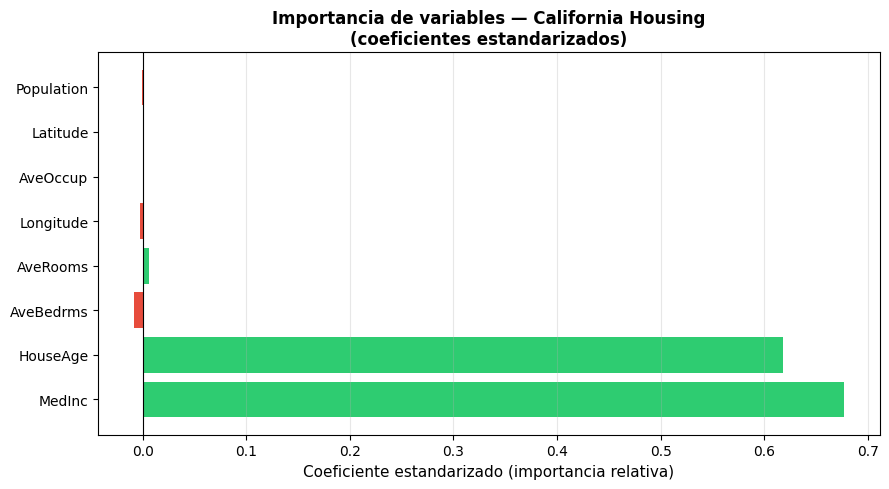

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# ESTANDARIZACIÓN DE VARIABLES (StandardScaler)
# ─────────────────────────────────────────────────────────────────────────────
# StandardScaler transforma cada variable X_j → (X_j - μ_j) / σ_j
# IMPORTANTE: fit_transform solo sobre TRAIN → evitamos "data leakage"
# (que información del test contamine el preprocesado).
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr_m)   # aprende μ y σ en train, y transforma
X_te_sc = scaler.transform(X_te_m)       # usa los mismos μ y σ para transformar test

# Entrenamos el mismo modelo sobre los datos estandarizados
modelo_std = LinearRegression()
modelo_std.fit(X_tr_sc, y_tr_m)

# El R² no cambia al estandarizar: solo interpretamos los coeficientes de otra forma
y_pred_std = modelo_std.predict(X_te_sc)
print(f"R² (estandarizado): {r2_score(y_te_m, y_pred_std):.4f}  — idéntico al modelo sin escalar")

# ─────────────────────────────────────────────────────────────────────────────
# TABLA DE IMPORTANCIA RELATIVA
# ─────────────────────────────────────────────────────────────────────────────
# Ordenamos por valor absoluto del coeficiente:
# el signo indica dirección (+ sube precio, - lo baja)
# el valor absoluto indica magnitud (importancia)
coef_std = pd.DataFrame({
    "variable":           X_multi.columns,
    "coef_estandarizado": modelo_std.coef_,
    "importancia_abs":    np.abs(modelo_std.coef_)
}).sort_values("importancia_abs", ascending=False)

print("\nImportancia relativa (coeficientes estandarizados, ordenados):")
print(coef_std[["variable","coef_estandarizado"]].to_string(index=False))

# ─────────────────────────────────────────────────────────────────────────────
# GRÁFICO DE BARRAS — importancia de variables
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

# Verde para coeficientes positivos (aumentan el precio), rojo para negativos
colores_std = ["#2ECC71" if c > 0 else "#E74C3C" for c in coef_std["coef_estandarizado"]]
ax.barh(coef_std["variable"], coef_std["coef_estandarizado"], color=colores_std)

ax.axvline(x=0, color="black", linewidth=0.8)   # línea de referencia en 0
ax.set_xlabel("Coeficiente estandarizado (importancia relativa)", fontsize=11)
ax.set_title("Importancia de variables — California Housing\n(coeficientes estandarizados)",
             fontsize=12, fontweight="bold")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()
